In [7]:
import sys
import os

project_root = "home/antoniocorvino/Projects/BuildingsExtraction/"

sys.path.append("..")

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

from src.models.factory import build_model

/home/antoniocorvino/Projects/BuildingsExtraction/notebooks
/home/antoniocorvino/Projects/BuildingsExtraction/notebooks


In [8]:
runs_path = "/home/antoniocorvino/Projects/BuildingsExtraction/runs/"

image_path = f"{runs_path}/example/10001146_image.tif"

model_path = f"{runs_path}/WHUBuildingDataset/"

model_paths = {
    "bce": f"{model_path}/unetLL_bce_dim256_n47088_bs32/best_model.pth",
    "tversky": f"{model_path}/unetLL_tversky_dim256_n47088_bs32/best_model.pth",
    "focal_tversky": f"{model_path}/unetLL_focal_tversky_dim256_n47088_bs32/best_model.pth",
}

arch = "unetLL"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
img = Image.open(image_path).convert("RGB")
img_np = np.array(img)

transform = transforms.ToTensor()
img_tensor = transform(img).unsqueeze(0).to(device)

In [10]:
def infer_model(model_path):
    model = build_model(arch).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    with torch.no_grad():
        logits = model(img_tensor)
        probs = torch.sigmoid(logits)

    return probs.squeeze().cpu().numpy()

In [11]:
probs = {}

for name, path in model_paths.items():
    print(f"Running {name}...")
    p = infer_model(path)
    probs[name] = p
    np.save(f"{runs_path}/example/{name}.npy", p)

print("Saved probability maps.")

Running bce...
Running tversky...
Running focal_tversky...
Saved probability maps.


In [13]:
p_bce = np.load(f"{runs_path}/example/bce.npy")
p_tversky = np.load(f"{runs_path}/example/tversky.npy")
p_focal = np.load(f"{runs_path}/example/focal_tversky.npy")

In [14]:
stack = np.stack([p_bce, p_tversky, p_focal], axis=0)

mean_map = np.mean(stack, axis=0)
var_map = np.var(stack, axis=0)

print("Mean range:", mean_map.min(), mean_map.max())
print("Variance range:", var_map.min(), var_map.max())

Mean range: 6.114912e-07 0.9999972
Variance range: 7.3005843e-13 0.22221856


In [15]:
def show_overlay(title, base_img, heatmap, cmap="jet", alpha=0.5):
    plt.figure(figsize=(6,6))
    plt.imshow(base_img)
    plt.imshow(heatmap, cmap=cmap, alpha=alpha)
    plt.title(title)
    plt.axis("off")
    plt.show()

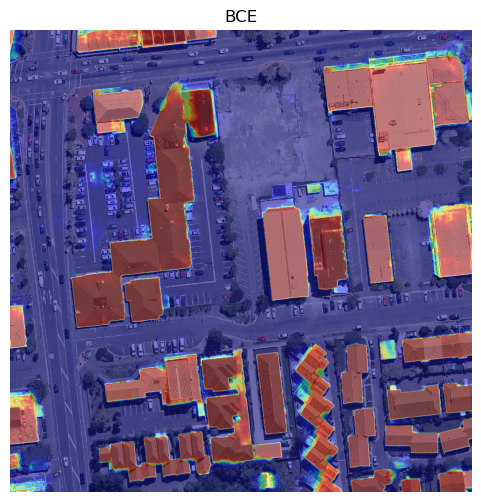

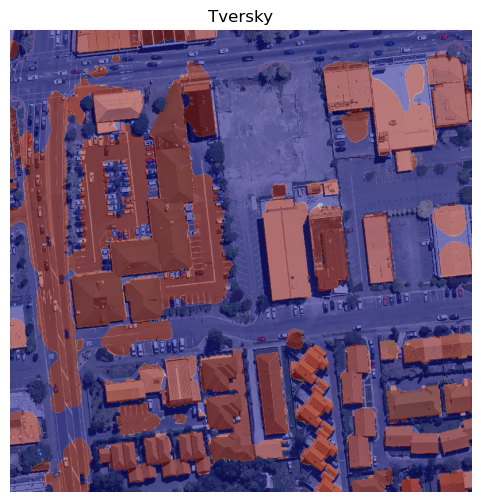

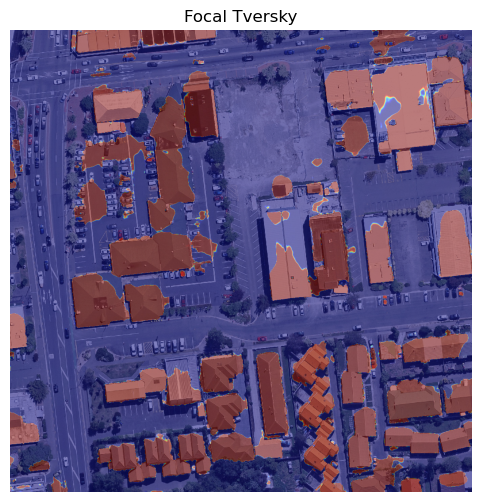

In [16]:
show_overlay("BCE", img_np, p_bce)
show_overlay("Tversky", img_np, p_tversky)
show_overlay("Focal Tversky", img_np, p_focal)

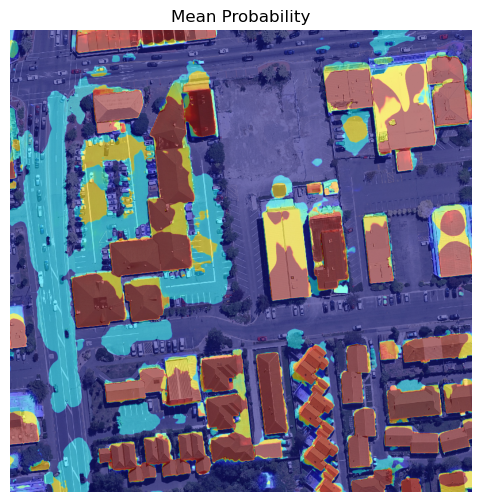

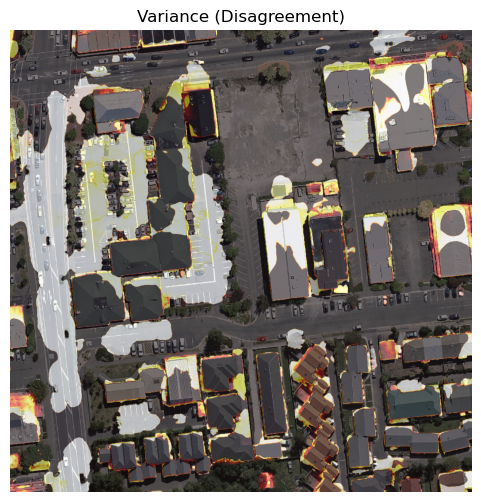

In [17]:
show_overlay("Mean Probability", img_np, mean_map)
show_overlay("Variance (Disagreement)", img_np, var_map, cmap="hot")

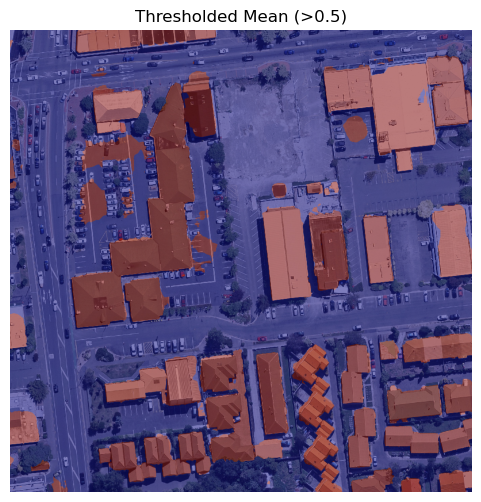

In [18]:
binary = mean_map > 0.5
show_overlay("Thresholded Mean (>0.5)", img_np, binary.astype(float))